In [1]:
from pathlib import Path
from itertools import product
import sys
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display

sys.path.append(os.path.abspath("../"))

from simulators.model_solver_real_data import SoftFireCA
from simulators.metrics import FireMetrics

# In this notebook, we will try to find the parameters alpha beta gamma and study their sensitivity on real data.

# Load and prepare the data

In [2]:
REAL_DATA_DIR = Path("../data/backtest/fire_example_45")

temp = np.load(REAL_DATA_DIR / "2022-07-12_temperature.npy")
wind_dir = np.load(REAL_DATA_DIR / "2022-07-12_wind_direction.npy")
wind_val = np.load(REAL_DATA_DIR / "2022-07-12_wind_val.npy")
humidity = np.load(REAL_DATA_DIR / "2022-07-13_humidity.npy")
height_grid = np.load(REAL_DATA_DIR / "altitude.npy")
ground = np.load(REAL_DATA_DIR / "ground_matrix.npy", allow_pickle=True)
fire_spread = np.load(REAL_DATA_DIR / "fire_spread.npy")

height_grid = height_grid.astype(np.float32)
wind_speed = wind_val.astype(np.float32)


if wind_speed.max() != wind_speed.min():
    wind_grid = ((wind_speed - wind_speed.min()) / (wind_speed.max() - wind_speed.min())).astype(np.float32)
else:
    wind_grid = np.zeros_like(wind_speed, dtype=np.float32)

non_burnable = ["water", "bay", "sand", "dune", "wetland", "military"]
forest = 1 - np.isin(ground, non_burnable).astype(np.float32)

N_FRAMES = len(fire_spread)
TIME_EVAL = N_FRAMES - 1

print("fire_spread:", fire_spread.shape, fire_spread.min(), fire_spread.max())
print("height_grid:", height_grid.shape, height_grid.min(), height_grid.max())
print("wind_grid:", wind_grid.shape, wind_grid.min(), wind_grid.max())
print("forest:", forest.shape, forest.min(), forest.max(), "burnable ratio:", forest.mean())

fire_spread: (7, 54, 54) 0.0 1.0
height_grid: (54, 54) 204.0 317.0
wind_grid: (54, 54) 0.0 1.0
forest: (54, 54) 0.0 1.0 burnable ratio: 0.6920439


In [3]:
LAND_PARAMS = {
    "bay":           (0.95,     0),
    "beach":         (0.30,     0),
    "brownfield":    (0.10,     0),
    "cemetery":      (0.35,    10),
    "coastline":     (0.70,     2),
    "dune":          (0.15,     3),
    "empty":         (0.10,     0),
    "forest":        (0.50,    40),
    "grass":         (0.30,     5),
    "grassland":     (0.30,     8),
    "industrial":    (0.05,     0),
    "meadow":        (0.45,    10),
    "military":      (0.20,     5),
    "residential":   (0.20,     5),
    "sand":          (0.10,     0),
    "scrub":         (0.25,    15),
    "tree":          (0.45,    25),
    "water":         (1.00,     0),
    "wetland":       (0.90,     5),
}


def ground_to_grids(ground, land_params=LAND_PARAMS):
    moisture_vals = np.array([v[0] for v in land_params.values()], dtype=np.float32)
    age_vals = np.array([v[1] for v in land_params.values()], dtype=np.float32)
    keys = list(land_params.keys())

    key_to_idx = {k: i for i, k in enumerate(keys)}
    idx_grid = np.vectorize(lambda x: key_to_idx.get(x, 0))(ground)

    return moisture_vals[idx_grid], age_vals[idx_grid]


moisture_grid, age_grid = ground_to_grids(ground)

moisture_grid = moisture_grid.astype(np.float32)
age_grid = age_grid.astype(np.float32)

print("moisture_grid:", moisture_grid.shape, moisture_grid.min(), moisture_grid.max())
print("age_grid:", age_grid.shape, age_grid.min(), age_grid.max())

moisture_grid: (54, 54) 0.05 1.0
age_grid: (54, 54) 0.0 40.0


In [4]:
ignition_point = [
    fire_spread[0].argmax() // fire_spread[0].shape[0],
    fire_spread[0].argmax() % fire_spread[0].shape[0],
]

ignition_value = fire_spread[0][ignition_point[0], ignition_point[1]]

FM_obs = FireMetrics(fire_spread, fire_spread)
arrival_time = FM_obs.arrival_time_G
arrival_time[np.isinf(arrival_time)] = -1
arrival_time = arrival_time.astype(np.float32)

print("Ignition point:", ignition_point)
print("Ignition value:", ignition_value)
print("arrival_time shape:", arrival_time.shape)
print("arrival_time min/max:", arrival_time.min(), arrival_time.max())
print("burned cells in ground truth:", int((arrival_time >= 0).sum()))

Ignition point: [np.int64(21), np.int64(28)]
Ignition value: 7.841371225840634e-05
arrival_time shape: (54, 54)
arrival_time min/max: -1.0 6.0
burned cells in ground truth: 1461


### Utilitary functions

In [5]:
def arrival_to_sequence(arrival, n_steps):
    if isinstance(arrival, torch.Tensor):
        arrival = arrival.detach().cpu().numpy()
    else:
        arrival = np.array(arrival)

    H, W = arrival.shape
    sequence = np.zeros((n_steps, H, W), dtype=np.float32)

    for t in range(1, n_steps):
        burned = (arrival <= t) & (arrival > t - 1)
        sequence[t] = sequence[t - 1] + burned.astype(np.float32)

    return sequence


def clean_predicted_arrival(arrival_prediction, max_time):
    if isinstance(arrival_prediction, torch.Tensor):
        arrival_prediction = arrival_prediction.detach().cpu().numpy()

    arrival_prediction = np.array(arrival_prediction, dtype=np.float32)
    arrival_prediction[~np.isfinite(arrival_prediction)] = -1
    arrival_prediction[arrival_prediction > max_time] = -1
    arrival_prediction = np.round(arrival_prediction)

    return arrival_prediction.astype(np.float32)


def iou_score(pred, obs):
    pred = np.asarray(pred, dtype=np.float32)
    obs = np.asarray(obs, dtype=np.float32)

    intersection = np.minimum(pred, obs).sum()
    union = np.maximum(pred, obs).sum()

    if union == 0.0:
        return 1.0

    return float(intersection / union)


def aatd_from_maps_safe(pred_arrival, obs_arrival):
    pred_arrival = np.asarray(pred_arrival, dtype=np.float32)
    obs_arrival = np.asarray(obs_arrival, dtype=np.float32)

    valid = (pred_arrival >= 0) & (obs_arrival >= 0)

    if valid.sum() == 0:
        return np.nan

    return float(np.mean(np.abs(pred_arrival[valid] - obs_arrival[valid])))

In [ ]:
def simulate_fire_candidate_softca(height_grid, age_grid, moisture_grid, wind_grid, ignition_point, ignition_value,  alpha,  beta, gamma,n_frames=N_FRAMES,  n_substeps=5, burn_mask=forest,):
    model = SoftFireCA(height_grid, age_grid, moisture_grid, alpha_init=alpha,  beta_init=beta,  gamma_init=gamma,   burn_mask=burn_mask,)

    model.eval()

    with torch.no_grad():
        arrival_prediction = model.forward(ignition_point, ignition_value, wind_grid,  n_frames,  n_substeps,)
    pred_sequence = arrival_to_sequence(arrival_prediction,  n_frames,)
    pred_final = pred_sequence[-1].astype(np.float32)

    pred_arrival_clean = clean_predicted_arrival(arrival_prediction,   max_time=n_frames - 1,)

    return {
        "arrival_prediction": arrival_prediction,
        "arrival_time": pred_arrival_clean,
        "sequence": pred_sequence,
        "final_state": pred_final,
    }

In [ ]:
def evaluate_softca_params(alpha, beta, gamma, n_substeps, time_eval=TIME_EVAL,):
    pred = simulate_fire_candidate_softca( height_grid=height_grid, age_grid=age_grid, moisture_grid=moisture_grid,wind_grid=wind_grid, ignition_point=ignition_point, ignition_value=ignition_value, alpha=alpha, beta=beta, gamma=gamma, n_frames=N_FRAMES, n_substeps=n_substeps,burn_mask=forest, )

    pred_sequence = pred["sequence"]
    pred_final = pred["final_state"]
    pred_arrival = pred["arrival_time"]

    obs_final = fire_spread[-1].astype(np.float32)

    iou = iou_score(pred_final, obs_final)
    aatd = aatd_from_maps_safe(pred_arrival, arrival_time)

    try:
        FM = FireMetrics(pred_sequence, fire_spread)
        shape_metrics = FM.all_shape_metrics(time_eval, time_eval)
        spread_metrics = FM.all_spread_metrics()
        metrics = shape_metrics | spread_metrics
    except Exception as e:
        metrics = {"firemetrics_error": str(e)}

    metrics.update(
        {
            "alpha": float(alpha),
            "beta": float(beta),
            "gamma": float(gamma),
            "n_substeps": int(n_substeps),
            "mean_iou": float(iou),
            "mean_iou_loss": float(1.0 - iou),
            "mean_aatd": float(aatd) if np.isfinite(aatd) else np.nan,
        }
    )

    return metrics

# Grid search

In [ ]:
alpha_grid = [0.2,0.3,0.5, 0.8,1,1.5, 2]
beta_grid = [ 0.05, 0.2,0.5,0.8,1,1.2]
gamma_grid = [0.01, 0.03, 0.05,0.1,0.3,0.5,0.7]

n_substeps_grid = [5,7, 9]

n_candidates = len(alpha_grid) * len(beta_grid) * len(gamma_grid) * len(n_substeps_grid)

print("Number of combinations:", n_candidates)

results = []

counter = 0

for alpha, beta, gamma, n_substeps in product(alpha_grid, beta_grid, gamma_grid, n_substeps_grid,):
    counter += 1

    print(f"[{counter}/{n_candidates}] " f"alpha={alpha}, beta={beta}, gamma={gamma}, n_substeps={n_substeps}" )

    try:
        row = evaluate_softca_params(
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            n_substeps=n_substeps,
            time_eval=TIME_EVAL,
        )
        results.append(row)

    except Exception as e:
        print("Error:", e)

results_df = pd.DataFrame(results)

display(results_df.head())
print(results_df.columns.tolist())

Nombre de combinaisons: 882
[1/882] alpha=0.2, beta=0.05, gamma=0.01, n_substeps=5
[2/882] alpha=0.2, beta=0.05, gamma=0.01, n_substeps=7
[3/882] alpha=0.2, beta=0.05, gamma=0.01, n_substeps=9
[4/882] alpha=0.2, beta=0.05, gamma=0.03, n_substeps=5
[5/882] alpha=0.2, beta=0.05, gamma=0.03, n_substeps=7
[6/882] alpha=0.2, beta=0.05, gamma=0.03, n_substeps=9
[7/882] alpha=0.2, beta=0.05, gamma=0.05, n_substeps=5
[8/882] alpha=0.2, beta=0.05, gamma=0.05, n_substeps=7
[9/882] alpha=0.2, beta=0.05, gamma=0.05, n_substeps=9
[10/882] alpha=0.2, beta=0.05, gamma=0.1, n_substeps=5
[11/882] alpha=0.2, beta=0.05, gamma=0.1, n_substeps=7
[12/882] alpha=0.2, beta=0.05, gamma=0.1, n_substeps=9
[13/882] alpha=0.2, beta=0.05, gamma=0.3, n_substeps=5
[14/882] alpha=0.2, beta=0.05, gamma=0.3, n_substeps=7
[15/882] alpha=0.2, beta=0.05, gamma=0.3, n_substeps=9
[16/882] alpha=0.2, beta=0.05, gamma=0.5, n_substeps=5
[17/882] alpha=0.2, beta=0.05, gamma=0.5, n_substeps=7
[18/882] alpha=0.2, beta=0.05, gamma=

,iou,l2_norm,wasserstein2,hausdorff,aatd,fde_radians,fde_degrees,alpha,beta,gamma,n_substeps,mean_iou,mean_iou_loss,mean_aatd
0,0.806135,0.316319,2.028677,4.472136,1.403574,0.878652,50.343051,0.2,0.05,0.01,5,0.806135,0.193865,1.375279
1,0.733541,0.401452,3.676848,11.180340,1.255257,0.872443,49.987310,0.2,0.05,0.01,7,0.733541,0.266459,1.251632
2,0.726590,0.409068,3.808036,13.601471,1.303118,0.657749,37.686236,0.2,0.05,0.01,9,0.726590,0.273410,1.310370
3,0.806233,0.315464,2.025498,5.000000,1.406881,0.874543,50.107613,0.2,0.05,0.03,5,0.806233,0.193767,1.379955
4,0.734712,0.400169,3.639721,10.440307,1.258158,0.876891,50.242126,0.2,0.05,0.03,7,0.734712,0.265288,1.250181


['iou', 'l2_norm', 'wasserstein2', 'hausdorff', 'aatd', 'fde_radians', 'fde_degrees', 'alpha', 'beta', 'gamma', 'n_substeps', 'mean_iou', 'mean_iou_loss', 'mean_aatd']


## Analysis of the results

In [9]:
sort_metric = "mean_iou_loss"

results_df_sorted = (
    results_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[sort_metric])
    .sort_values(sort_metric)
    .reset_index(drop=True)
)

display(results_df_sorted.head(20))

best = results_df_sorted.iloc[0]

best_alpha = float(best["alpha"])
best_beta = float(best["beta"])
best_gamma = float(best["gamma"])
best_substeps = int(best["n_substeps"])

print("Best parameters:")
print(f"alpha      = {best_alpha}")
print(f"beta       = {best_beta}")
print(f"gamma      = {best_gamma}")
print(f"n_substeps = {best_substeps}")
print(f"mean_iou      = {best['mean_iou']}")
print(f"mean_iou_loss = {best['mean_iou_loss']}")
print(f"mean_aatd     = {best['mean_aatd']}")

,iou,l2_norm,wasserstein2,hausdorff,aatd,fde_radians,fde_degrees,alpha,beta,gamma,n_substeps,mean_iou,mean_iou_loss,mean_aatd
0,0.826418,0.290620,2.089560,6.000000,1.469341,0.871895,49.955914,0.8,0.20,0.03,5,0.826418,0.173582,1.438304
1,0.826079,0.290127,2.135874,6.000000,1.470722,0.874657,50.114135,1.0,0.20,0.03,5,0.826079,0.173921,1.438023
2,0.825639,0.291031,2.119658,5.385165,1.462822,0.884269,50.664888,1.0,0.20,0.01,5,0.825639,0.174361,1.439302
3,0.825229,0.292297,2.087555,5.385165,1.459215,0.915854,52.474566,0.8,0.20,0.01,5,0.825229,0.174771,1.438066
4,0.824566,0.291796,2.120189,6.324555,1.477169,0.851391,48.781124,0.8,0.20,0.05,5,0.824566,0.175434,1.446728
5,0.824359,0.294598,2.128790,4.472136,1.432210,0.940929,53.911253,1.0,0.05,0.01,5,0.824359,0.175641,1.398502
6,0.823886,0.290392,2.226768,7.211103,1.485362,0.813479,46.608931,0.8,0.20,0.10,5,0.823886,0.176114,1.456857
7,0.823672,0.293900,2.148828,5.000000,1.430514,0.909386,52.103972,1.0,0.05,0.05,5,0.823672,0.176328,1.404834
8,0.823513,0.293555,2.116440,6.324555,1.445372,0.865328,49.579665,0.8,0.05,0.10,5,0.823513,0.176487,1.415023
9,0.822506,0.295832,2.148778,5.000000,1.434488,0.933341,53.476508,1.0,0.05,0.03,5,0.822506,0.177494,1.400602


Best parameters:
alpha      = 0.8
beta       = 0.2
gamma      = 0.03
n_substeps = 5
mean_iou      = 0.8264182806015015
mean_iou_loss = 0.17358171939849854
mean_aatd     = 1.4383043050765991


# Visualisations

IoU final: 0.8264182806015015
Observed final min/max: 0.0 1.0
Predicted final min/max: 0.0 1.0
Observed burned cells > 0: 1580
Predicted burned cells > 0: 1459


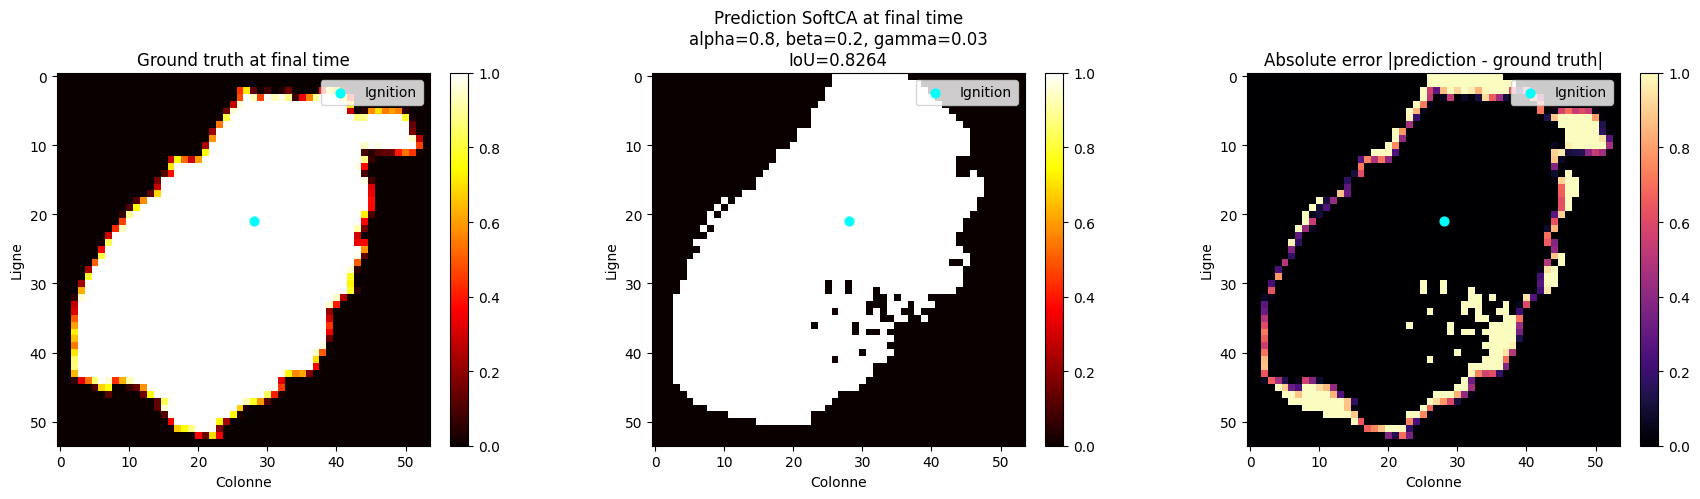

In [10]:
best_pred = simulate_fire_candidate_softca(
    height_grid=height_grid,
    age_grid=age_grid,
    moisture_grid=moisture_grid,
    wind_grid=wind_grid,
    ignition_point=ignition_point,
    ignition_value=ignition_value,
    alpha=best_alpha,
    beta=best_beta,
    gamma=best_gamma,
    n_frames=N_FRAMES,
    n_substeps=best_substeps,
    burn_mask=forest,
)

pred_final = best_pred["final_state"].astype(np.float32)
obs_final = fire_spread[-1].astype(np.float32)

final_iou = iou_score(pred_final, obs_final)

i0, j0 = int(ignition_point[0]), int(ignition_point[1])

print("IoU final:", final_iou)
print("Observed final min/max:", obs_final.min(), obs_final.max())
print("Predicted final min/max:", pred_final.min(), pred_final.max())
print("Observed burned cells > 0:", int((obs_final > 0).sum()))
print("Predicted burned cells > 0:", int((pred_final > 0).sum()))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

im0 = axs[0].imshow(obs_final, cmap="hot", vmin=0, vmax=1)
axs[0].scatter([j0], [i0], c="cyan", s=40, label="Ignition")
axs[0].set_title("Ground truth at final time")
axs[0].set_xlabel("Colonne")
axs[0].set_ylabel("Ligne")
axs[0].legend(loc="upper right")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(pred_final, cmap="hot", vmin=0, vmax=1)
axs[1].scatter([j0], [i0], c="cyan", s=40, label="Ignition")
axs[1].set_title(
    f"Prediction SoftCA at final time\n"
    f"alpha={best_alpha}, beta={best_beta}, gamma={best_gamma}\n"
    f"IoU={final_iou:.4f}"
)
axs[1].set_xlabel("Colonne")
axs[1].set_ylabel("Ligne")
axs[1].legend(loc="upper right")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

diff = np.abs(pred_final - obs_final)

im2 = axs[2].imshow(diff, cmap="magma", vmin=0, vmax=1)
axs[2].scatter([j0], [i0], c="cyan", s=40, label="Ignition")
axs[2].set_title("Absolute error |prediction - ground truth|")
axs[2].set_xlabel("Colonne")
axs[2].set_ylabel("Ligne")
axs[2].legend(loc="upper right")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Heatmaps to study the sensitivity

In [11]:

metric_to_plot = "mean_iou"  # larger is better for IoU

best_for_heatmap = (
    results_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[metric_to_plot])
    .sort_values(metric_to_plot, ascending=False)
    .iloc[0]
)

fixed_alpha = float(best_for_heatmap["alpha"])
fixed_beta = float(best_for_heatmap["beta"])
fixed_gamma = float(best_for_heatmap["gamma"])

if "n_substeps" in results_df.columns:
    fixed_substeps = int(best_for_heatmap["n_substeps"])
else:
    fixed_substeps = None

print("Best point according to IoU :")
print(f"alpha = {fixed_alpha}")
print(f"beta  = {fixed_beta}")
print(f"gamma = {fixed_gamma}")

if fixed_substeps is not None:
    print(f"n_substeps = {fixed_substeps}")

print(f"IoU = {best_for_heatmap['mean_iou']}")

Best point according to IoU :
alpha = 0.8
beta  = 0.2
gamma = 0.03
n_substeps = 5
IoU = 0.8264182806015015


In [12]:
def plot_param_heatmap_iou(
    df,
    x_param,
    y_param,
    fixed_param,
    fixed_value,
    fixed_substeps=None,
):
    df_plot = df.copy()

    if fixed_substeps is not None and "n_substeps" in df_plot.columns:
        df_plot = df_plot[df_plot["n_substeps"] == fixed_substeps]

    df_plot = df_plot[np.isclose(df_plot[fixed_param], fixed_value)]

    if df_plot.empty:
        print(f"No data for {fixed_param} = {fixed_value}")
        return

    heatmap = df_plot.pivot_table(
        index=y_param,
        columns=x_param,
        values="mean_iou",
        aggfunc="mean",
    )

    if heatmap.empty:
        print(f"Heatmap empty for {x_param}/{y_param} with {fixed_param}={fixed_value}")
        return

    x_values = heatmap.columns.values
    y_values = heatmap.index.values

    plt.figure(figsize=(8, 6))

    im = plt.imshow(
        heatmap.values,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
    )

    plt.xticks(
        ticks=np.arange(len(x_values)),
        labels=[f"{v:g}" for v in x_values],
        rotation=45,
    )

    plt.yticks(
        ticks=np.arange(len(y_values)),
        labels=[f"{v:g}" for v in y_values],
    )

    plt.xlabel(x_param)
    plt.ylabel(y_param)

    title = f"IoU for {y_param} / {x_param}\n{fixed_param} fixed at {fixed_value:g}"

    if fixed_substeps is not None:
        title += f", n_substeps={fixed_substeps}"

    plt.title(title)
    plt.colorbar(im, label="mean_iou")

    best_x = float(best_for_heatmap[x_param])
    best_y = float(best_for_heatmap[y_param])

    x_match = np.where(np.isclose(x_values.astype(float), best_x))[0]
    y_match = np.where(np.isclose(y_values.astype(float), best_y))[0]

    if len(x_match) > 0 and len(y_match) > 0:
        plt.scatter(
            x_match[0],
            y_match[0],
            c="red",
            s=90,
            marker="x",
            label="Best IoU",
        )
        plt.legend()

    plt.tight_layout()
    plt.show()

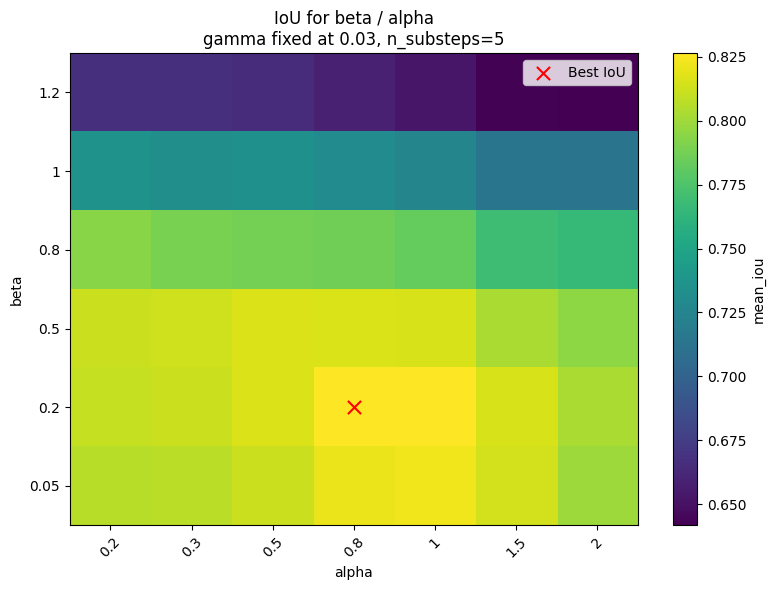

In [13]:
# Heatmap alpha / beta with gamma fixed at best value

plot_param_heatmap_iou(
    df=results_df,
    x_param="alpha",
    y_param="beta",
    fixed_param="gamma",
    fixed_value=fixed_gamma,
    fixed_substeps=fixed_substeps,
)

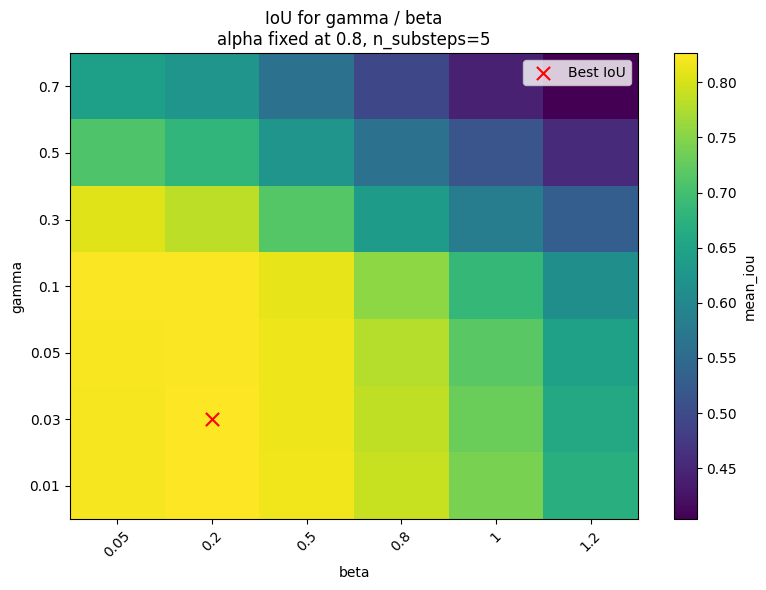

In [14]:
# Heatmap beta / gamma with alpha fixed at best value

plot_param_heatmap_iou(
    df=results_df,
    x_param="beta",
    y_param="gamma",
    fixed_param="alpha",
    fixed_value=fixed_alpha,
    fixed_substeps=fixed_substeps,
)

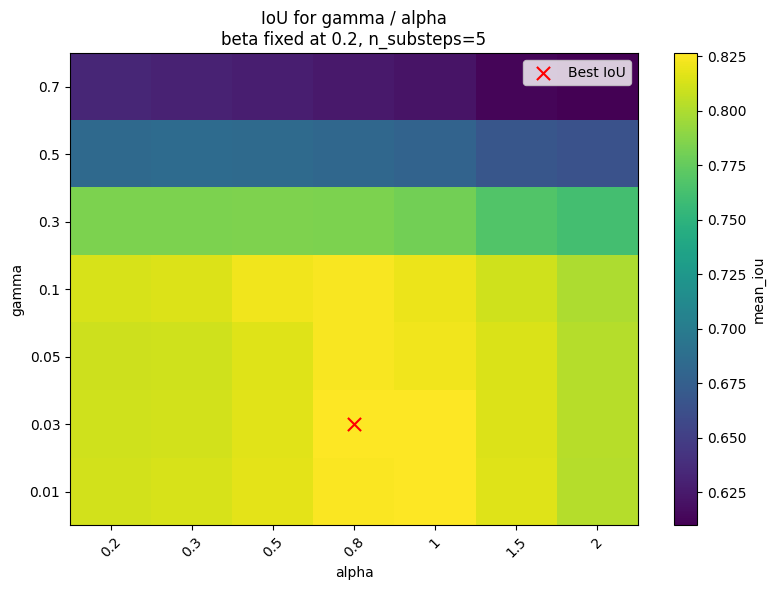

In [15]:
# Heatmap alpha / gamma with beta fixed at best value

plot_param_heatmap_iou(
    df=results_df,
    x_param="alpha",
    y_param="gamma",
    fixed_param="beta",
    fixed_value=fixed_beta,
    fixed_substeps=fixed_substeps,
)